<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_1/hw_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

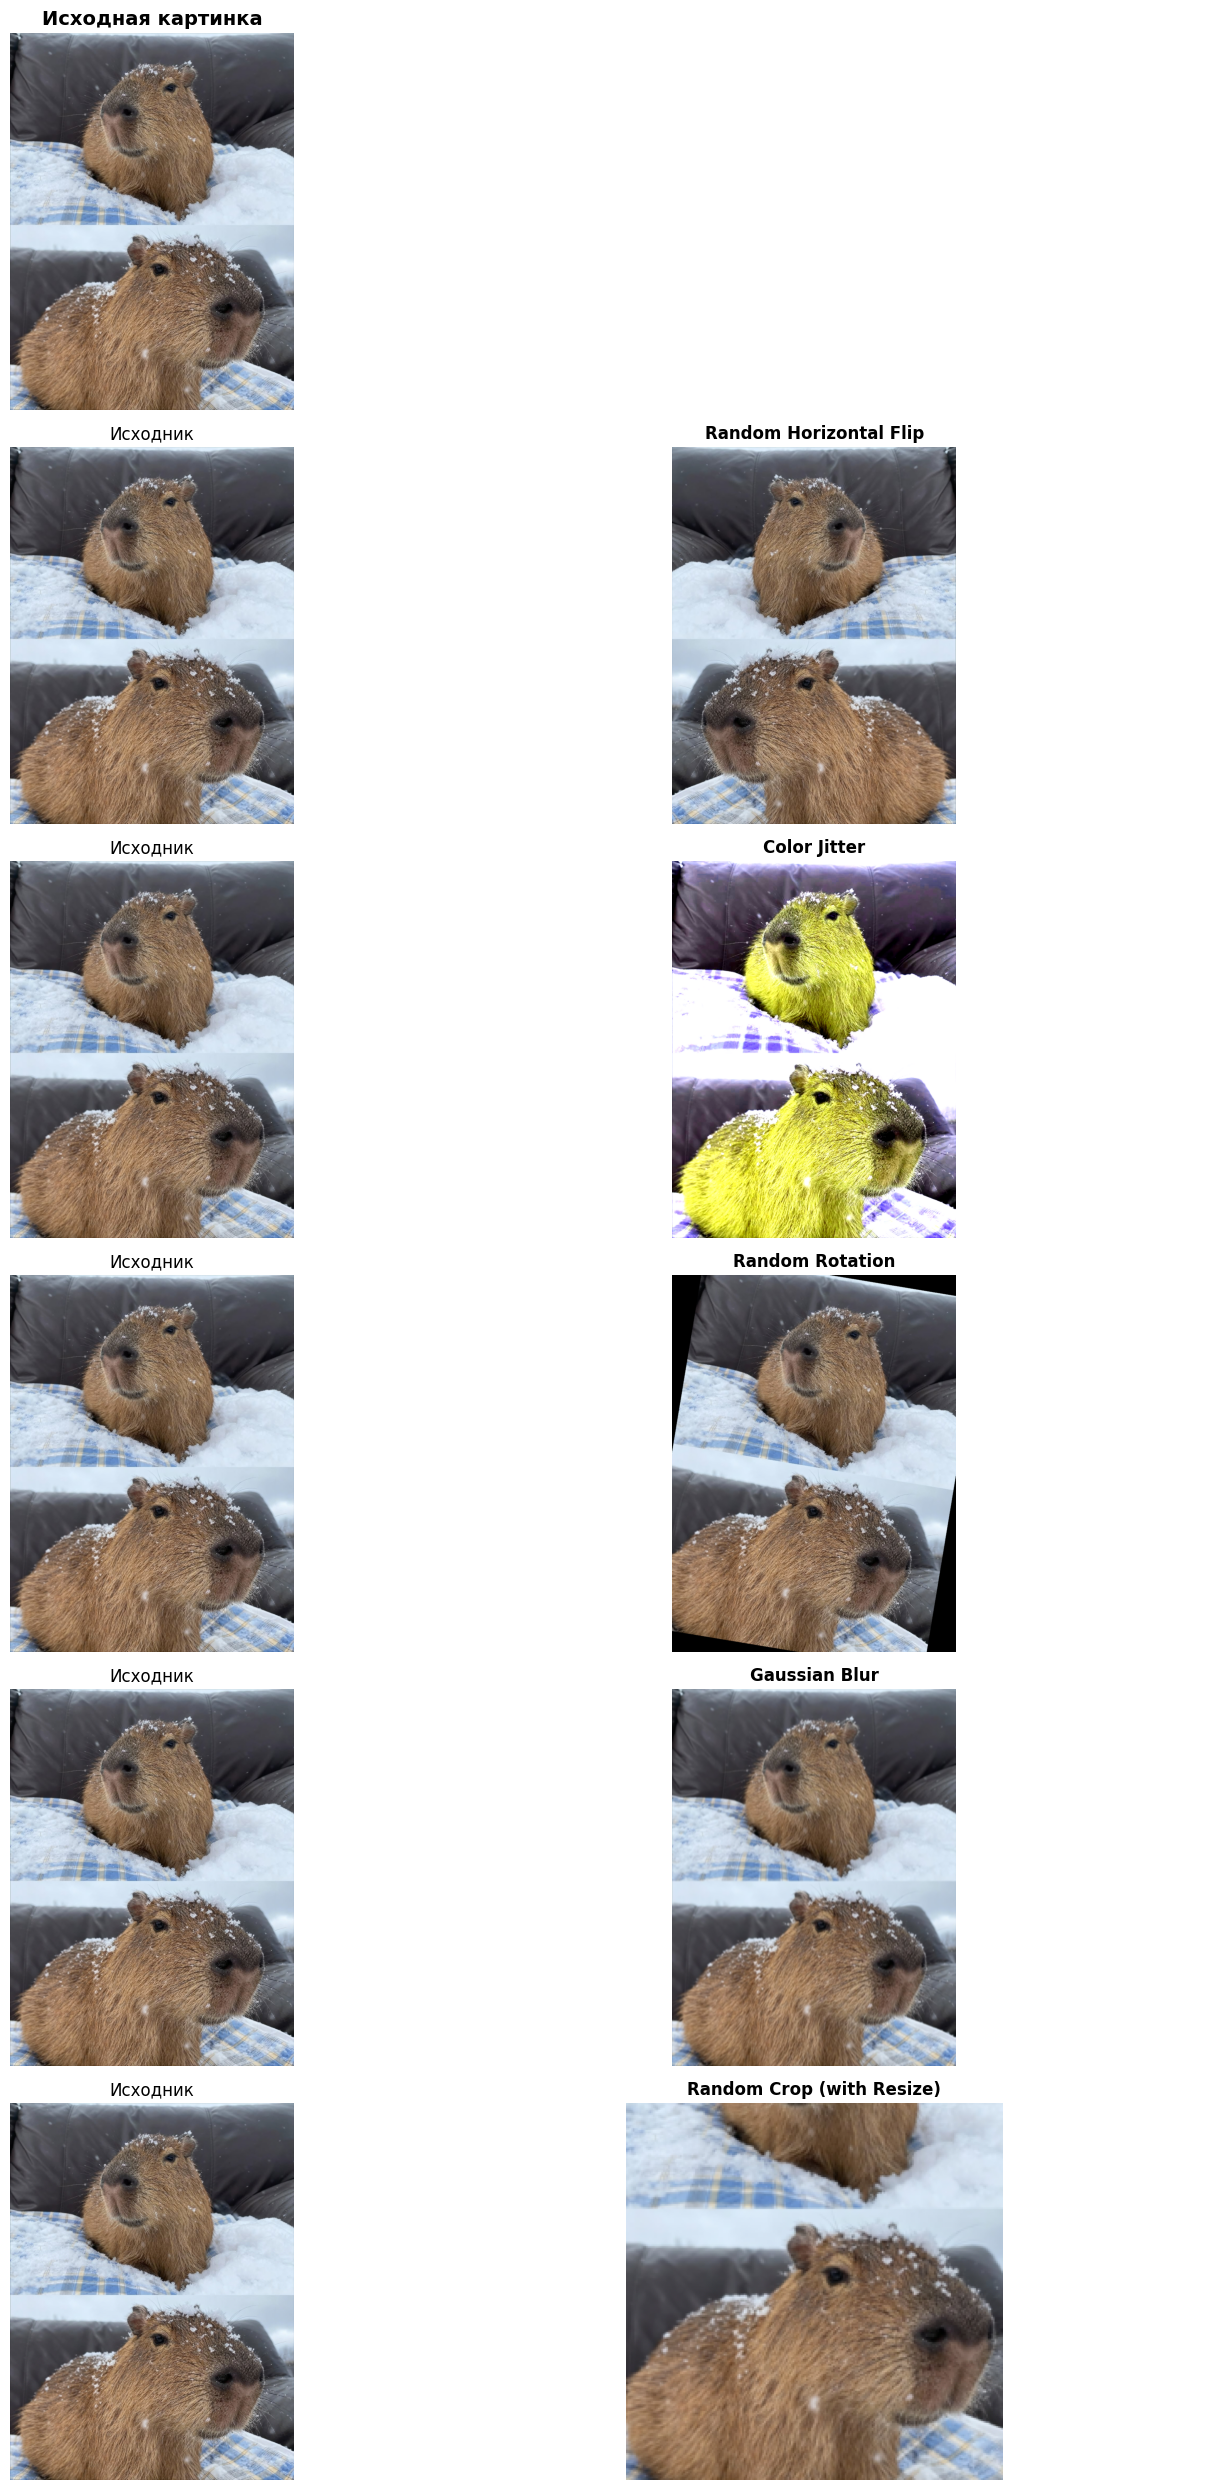

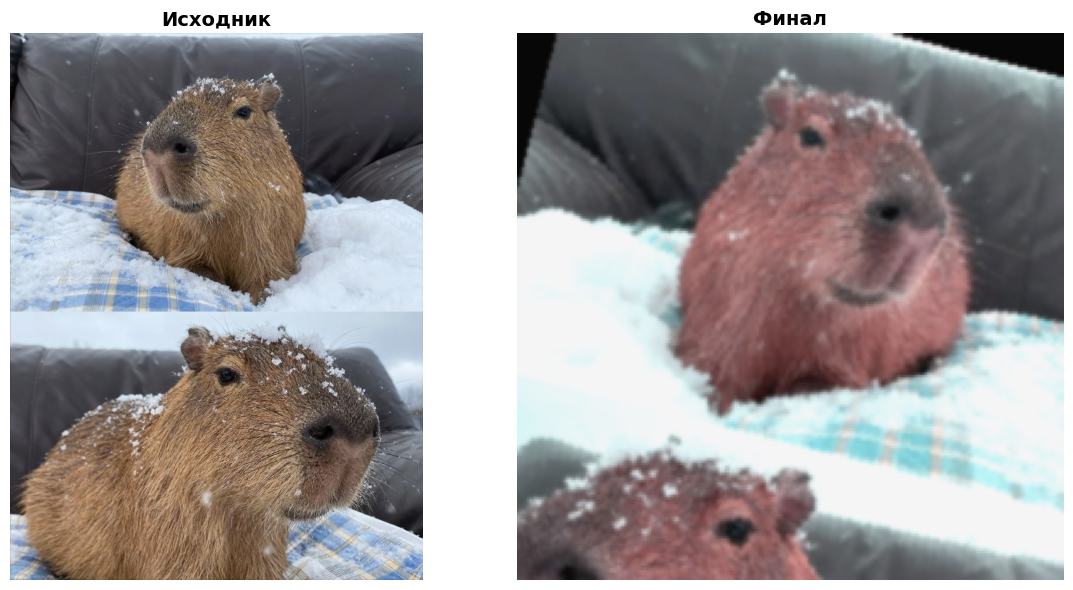

In [ ]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


image_path = "hb.jpg"
original_image = Image.open(image_path).convert("RGB")


to_tensor = transforms.ToTensor()
tensor_image = to_tensor(original_image)

augmentations = [
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.7, hue=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224)
    ])
]

augmentation_names = [
    "Random Horizontal Flip",
    "Color Jitter",
    "Random Rotation",
    "Gaussian Blur",
    "Random Crop (with Resize)"
]


fig, axes = plt.subplots(len(augmentations) + 1, 2, figsize=(15, 25))


axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Исходная картинка", fontsize=14, fontweight='bold')
axes[0, 0].axis('off')
axes[0, 1].axis('off')


for i, (aug, name) in enumerate(zip(augmentations, augmentation_names)):
    augmented_tensor = aug(tensor_image.clone())
    to_pil = transforms.ToPILImage()
    augmented_image = to_pil(augmented_tensor)


    axes[i+1, 0].imshow(original_image)
    axes[i+1, 0].set_title("Исходник", fontsize=12)
    axes[i+1, 0].axis('off')


    axes[i+1, 1].imshow(augmented_image)
    axes[i+1, 1].set_title(name, fontsize=12, fontweight='bold')
    axes[i+1, 1].axis('off')

plt.tight_layout()
plt.savefig("augmentation_results.jpg", bbox_inches='tight', dpi=150)
plt.show()

full_pipeline = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomCrop(224),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


final_tensor = full_pipeline(original_image)
final_image = transforms.ToPILImage()(final_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1))


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_image)
axes[0].set_title("Исходник", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(final_image)
axes[1].set_title("Финал", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig("full_pipeline_result.jpg", bbox_inches='tight', dpi=150)
plt.show()

1. Random Horizontal Flip (p=1.0)
Зеркально отражает изображение по горизонтали

2. Color Jitter
Изменяет яркость, контраст, насыщенность и оттенок

3. Random Rotation (30°)
Поворачивает изображение на случайный угол до 30 градусов

4. Gaussian Blur
Размывает изображение гауссовым фильтром

5. Random Crop (с Resize)
Обрезает случайную часть и меняет размер
